In [1]:
import numpy as np
import pandas as pd
import mathplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'mathplotlib'

In [3]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv(r'healthcare-dataset-stroke-data.csv')

In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
df.shape

(5110, 12)

In [8]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [11]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [12]:
df.isnull()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,False,False,False,False,False,False,False,False,False,True,False,False
5106,False,False,False,False,False,False,False,False,False,False,False,False
5107,False,False,False,False,False,False,False,False,False,False,False,False
5108,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [19]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5105    False
5106    False
5107    False
5108    False
5109    False
Length: 5110, dtype: bool

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
Categorical: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


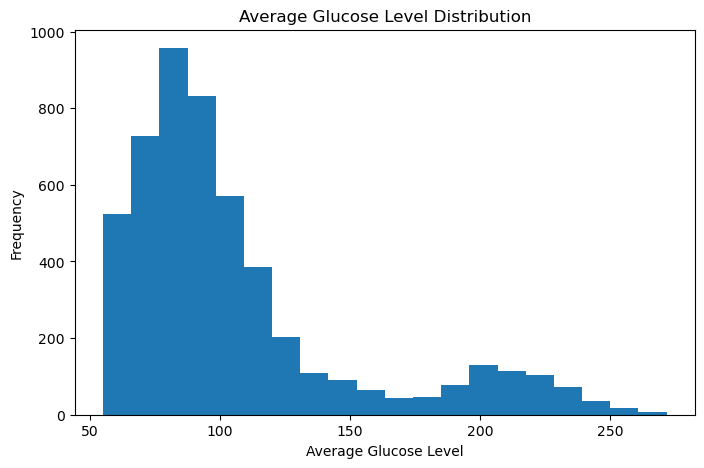

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(df['avg_glucose_level'], bins=20)
plt.title('Average Glucose Level Distribution')
plt.xlabel('Average Glucose Level')
plt.ylabel('Frequency')
plt.show()

observation for the above graph:  Most people have average glucose levels between 70 and 120. The graph is not evenly spread because there are a few people with very high glucose levels (above 180). This creates a long tail on the right side of the graph. Overall, the data shows that high glucose levels are less common, while normal to moderate glucose levels are more common.

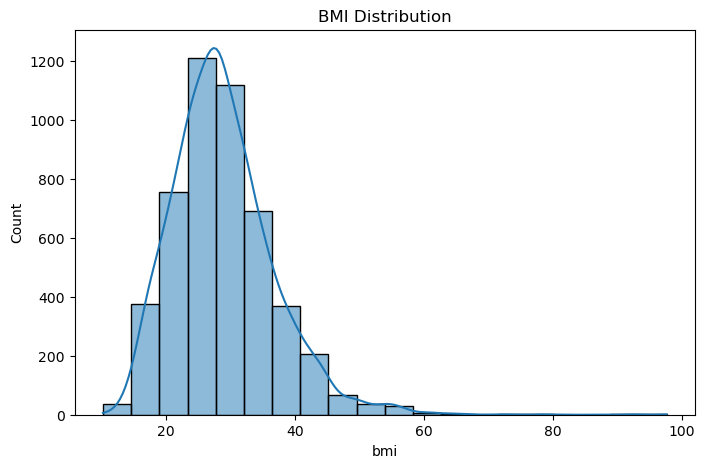

In [29]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df['bmi'].dropna(), bins=20, kde=True)
plt.title('BMI Distribution')
plt.show()

observation for the above graph:  Most people have a BMI between 20 and 35. The highest number of people have a BMI around 25 to 30. There are only a few people with very high BMI values (above 40), which creates a long tail on the right side of the graph. This shows that extremely high BMI values are uncommon in the dataset.

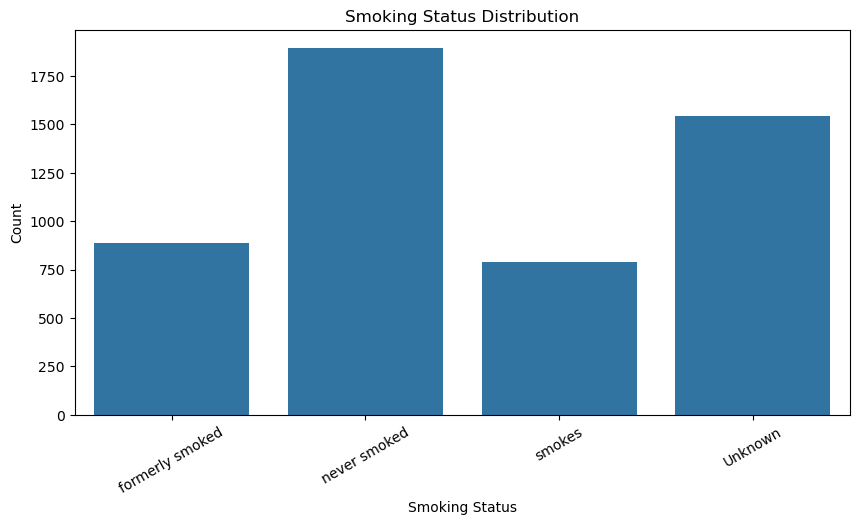

In [30]:
plt.figure(figsize=(10, 5))
sns.countplot(x='smoking_status', data=df)
plt.title('Smoking Status Distribution')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

observation for the above graph:  Most people in the dataset have never smoked. The second largest group has an unknown smoking status. The number of current smokers and former smokers is much lower compared to people who never smoked. This shows that non-smokers make up the largest portion of the dataset.

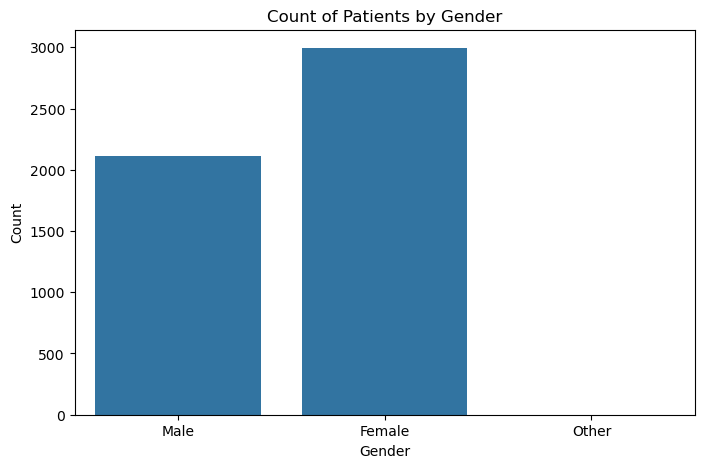

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=df)
plt.title('Count of Patients by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

observation for the above graph: The dataset contains more female patients than male patients. Female patients form the largest group, while male patients make up a slightly smaller portion. The 'Other' gender category has very few or no records compared to the other two categories. 

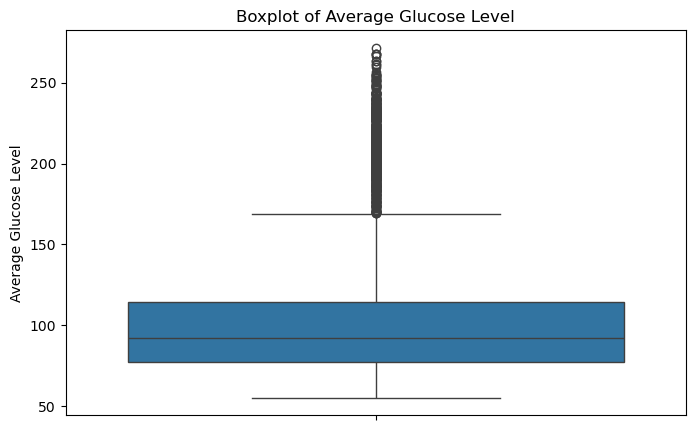

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(y='avg_glucose_level', data=df)
plt.title('Boxplot of Average Glucose Level')
plt.ylabel('Average Glucose Level')
plt.show()

observation :  The Normal Range: Most people (the blue box) have a normal average glucose level between 80 and 120, with the middle point sitting around 90. The Lowest Values: The lowest typical glucose levels go down to about 60 (the bottom line). The High Outliers: There is a huge, dense stack of dots at the top starting from 170 up to 270. These are unusually high values (statistical outliers) that stand out completely from the rest of the group. Overall Shape: The data is heavily skewed toward the higher side because of that long trail of high glucose levels.

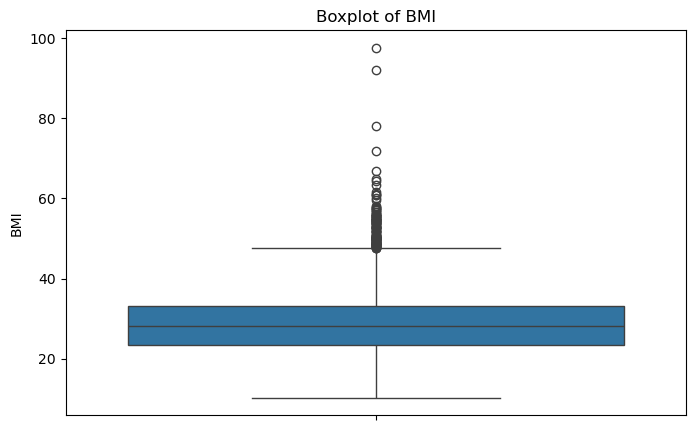

In [33]:
tdf = df.dropna(subset=['bmi'])

plt.figure(figsize=(8, 5))
sns.boxplot(y='bmi', data=tdf)
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.show()

observation : The Normal Range: Most people (the blue box) have a BMI between 25 and 35, with the exact middle sitting right around 30. The Lowest Values: The lowest standard BMI values go down to about 10 (the bottom line). The High Outliers: There is a long trail of dots going up past the top line (which is at about 50). A huge cluster of people have unusually high BMIs, stretching all the way up near 100. Overall Shape: Just like the glucose graph, this data is heavily skewed upward because of the massive number of high-BMI outliers.

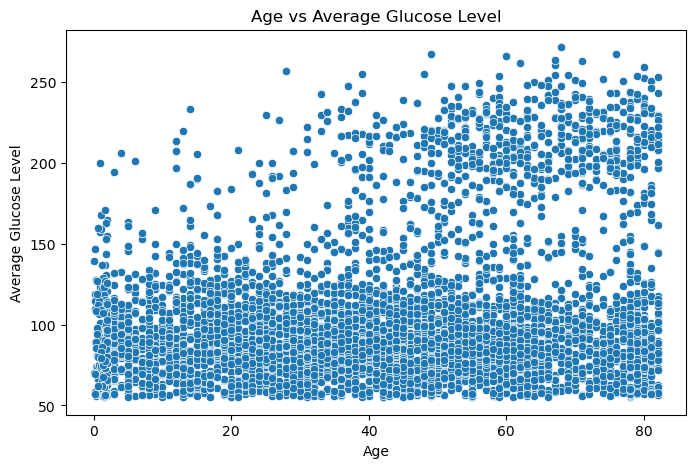

In [34]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='avg_glucose_level', data=df)

plt.title('Age vs Average Glucose Level')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.show()

observation : The Common Base: Across all ages (from 0 to 80+), there is a very dense, solid blue block of dots at the bottom between 50 and 130. This shows that a huge portion of people maintain a normal glucose level regardless of how old they are. The Age Trend: Look at how the dots spread out as you move from left to right. For younger people (ages 0 to 20), very few dots go above 150. But as age increases (especially past 40), the dots spread way higher, reaching all the way up to 250+. Main Takeaway: Higher, abnormal average glucose levels become much more common and frequent as people get older.

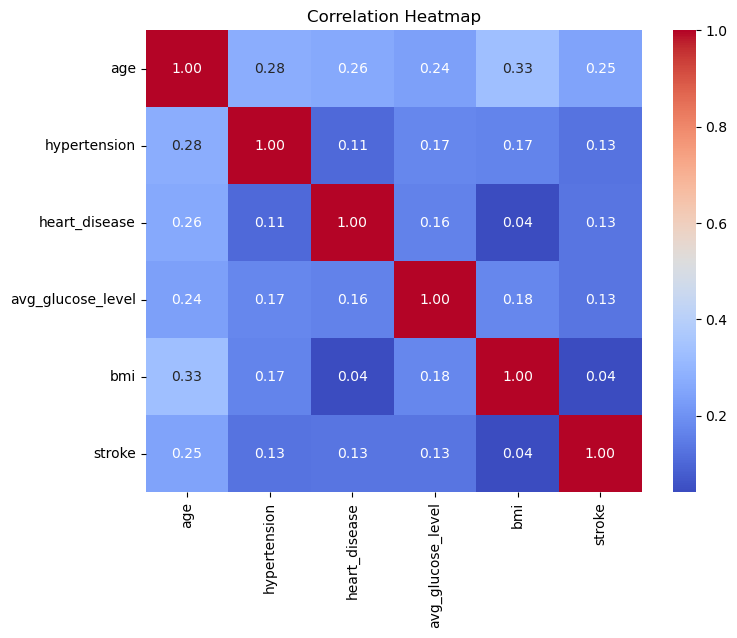

In [35]:
num_cols = ['age', 'hypertension', 'heart_disease',
            'avg_glucose_level', 'bmi', 'stroke']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

observation :  The Red Diagonal (1.00): The solid red line running from the top-left to bottom-right is just each variable matching with itself (e.g., age vs age). The Strongest Link (Age): Age has the highest correlation with almost every other health factor. Its strongest link is with BMI (0.33), followed closely by hypertension (0.28) and heart disease (0.26). This means as people get older, these health metrics tend to go up. The Weakest Link: BMI and stroke (0.04), as well as BMI and heart disease (0.04), have almost zero correlation (represented by the dark blue squares). In this dataset, a higher BMI doesn't directly guarantee a stroke or heart disease on its own. Main Takeaway: Overall, all the factors have a positive relationship with one another, but they are relatively weak to moderate links. Age is the most influential factor connecting them all.

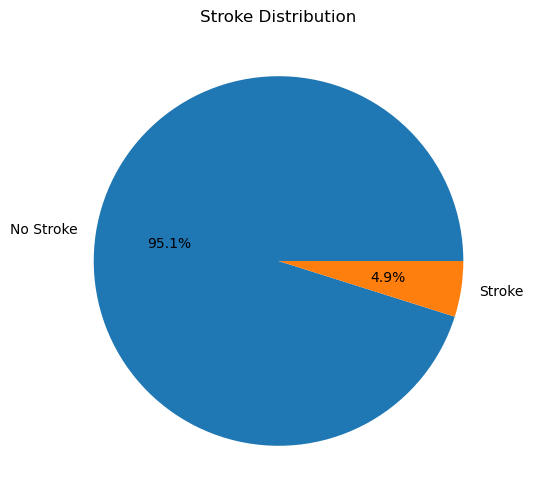

In [36]:
stroke_counts = df['stroke'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    stroke_counts,
    labels=['No Stroke', 'Stroke'],
    autopct='%1.1f%%'
)

plt.title('Stroke Distribution')
plt.show()

observation :  Massive Imbalance: The dataset is overwhelmingly dominated by one group. A massive 95.1% of the individuals in this data have never had a stroke (the blue slice). The Minority Group: Only a tiny fraction, 4.9%, of the individuals have had a stroke (the orange slice).